In [1]:
import re
from pathlib import Path
from itertools import product

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.style.use("../clane.v2.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [3]:
paths = sorted(Path("output").rglob("*/eval_[0-9]/*/train_log.json"))
print(len(paths))

tables = []
for path in paths:
    try:
        table = pd.read_json(path, lines=True)
    except ValueError:
        print("error:", path)
        continue
    key = path.parts[-4]
    match = re.search(r"(schaefer400|mni_cortex|flat)_lr([-0-9e]+)_([0-9])", key)
    space, lr, trial = match.groups()
    dataset, repr_, clf = path.parts[-2].split("__")
    version = int(path.parts[-3].split("_")[-1])
    table.insert(0, "dataset", dataset)
    table.insert(0, "trial", int(trial))
    table.insert(0, "base_lr", float(lr))
    table.insert(0, "space", space)
    table.insert(0, "version", version)
    tables.append(table)
table = pd.concat(tables, ignore_index=True)
print(table.shape)
table.head()

185
error: output/_old/mni_cortex_mask_flip/mni_cortex_lr1e-3_8/eval_5/hcpya_task21__patch__attn/train_log.json
(4080, 731)


,version,space,base_lr,trial,dataset,epoch,train/lr,train/loss,train/grad,train/loss_000_lr2.0e-02_wd1.0e+00,...,validation/f1_039_lr8.7e+00_wd1.0e+00,validation/f1_040_lr1.0e+01_wd1.0e+00,validation/f1_041_lr1.2e+01_wd1.0e+00,validation/f1_042_lr1.3e+01_wd1.0e+00,validation/f1_043_lr1.5e+01_wd1.0e+00,validation/f1_044_lr1.8e+01_wd1.0e+00,validation/f1_045_lr2.1e+01_wd1.0e+00,validation/f1_046_lr2.4e+01_wd1.0e+00,validation/f1_047_lr2.7e+01_wd1.0e+00,validation/f1_048_lr3.2e+01_wd1.0e+00
0,4,mni_cortex,0.001,1,hcpya_task21,0,0.0001,2.039350,0.217720,2.989401,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,mni_cortex,0.001,1,hcpya_task21,1,0.0003,1.565026,0.501997,2.786856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,mni_cortex,0.001,1,hcpya_task21,2,0.0005,3.066435,1.212896,2.558832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,mni_cortex,0.001,1,hcpya_task21,3,0.0007,4.723816,1.629562,2.328445,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,mni_cortex,0.001,1,hcpya_task21,4,0.0009,6.065721,1.881190,2.055153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# fmt: off
hparam_grids = {
    1: (
        [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
        [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
    ),
    2: (
        [0.032, 0.037, 0.042, 0.049, 0.056, 0.065, 0.075, 0.087, 0.1, 0.12, 0.13, 0.15, 0.18, 0.21, 0.24, 0.27, 0.32, 0.37, 0.42, 0.49, 0.56, 0.65, 0.75, 0.87, 1, 1.2, 1.3, 1.5, 1.8, 2.1, 2.4, 2.7, 3.2, 3.7, 4.2, 4.9, 5.6, 6.5, 7.5, 8.7, 10, 12, 13, 15, 18, 21, 24, 27, 32],
        [1.0],
    ),
    3: (
        [0.032, 0.037, 0.042, 0.049, 0.056, 0.065, 0.075, 0.087, 0.1, 0.12, 0.13, 0.15, 0.18, 0.21, 0.24, 0.27, 0.32, 0.37, 0.42, 0.49, 0.56, 0.65, 0.75, 0.87, 1, 1.2, 1.3, 1.5, 1.8, 2.1, 2.4, 2.7, 3.2, 3.7, 4.2, 4.9, 5.6, 6.5, 7.5, 8.7, 10, 12, 13, 15, 18, 21, 24, 27, 32],
        [1.0],
    ),
    4: (
        [0.02, 0.023, 0.028, 0.033, 0.038, 0.045, 0.053, 0.062, 0.074, 0.087, 0.1, 0.12, 0.14, 0.17, 0.2, 0.23, 0.27, 0.32, 0.38, 0.44, 0.52, 0.61, 0.72, 0.85, 1, 1.2, 1.4, 1.6, 1.9, 2.3, 2.7, 3.1, 3.7, 4.3, 5.1, 6, 7.1, 8.3, 9.8, 12, 14, 16, 19, 22, 26, 31, 36, 43, 50],
        [1.0],
    ),
    5: (
        [0.02, 0.023, 0.028, 0.033, 0.038, 0.045, 0.053, 0.062, 0.074, 0.087, 0.1, 0.12, 0.14, 0.17, 0.2, 0.23, 0.27, 0.32, 0.38, 0.44, 0.52, 0.61, 0.72, 0.85, 1, 1.2, 1.4, 1.6, 1.9, 2.3, 2.7, 3.1, 3.7, 4.3, 5.1, 6, 7.1, 8.3, 9.8, 12, 14, 16, 19, 22, 26, 31, 36, 43, 50],
        [1.0],
    ),
    6: (
        [0.02, 0.023, 0.028, 0.033, 0.038, 0.045, 0.053, 0.062, 0.074, 0.087, 0.1, 0.12, 0.14, 0.17, 0.2, 0.23, 0.27, 0.32, 0.38, 0.44, 0.52, 0.61, 0.72, 0.85, 1, 1.2, 1.4, 1.6, 1.9, 2.3, 2.7, 3.1, 3.7, 4.3, 5.1, 6, 7.1, 8.3, 9.8, 12, 14, 16, 19, 22, 26, 31, 36, 43, 50],
        [1.0],
    ),
}
# fmt: on


def format_hparam(ii, jj, version=1):
    lr_scale_grid, wd_scale_grid = hparam_grids[version]
    lr = lr_scale_grid[ii]
    wd = wd_scale_grid[jj]
    idx = ii * len(wd_scale_grid) + jj
    s = f"{idx:03d}_lr{lr:.1e}_wd{wd:.1e}"
    return s


space_lrs = {
    "schaefer400": 3e-4,
    "flat": 1e-3,
    "mni_cortex": 1e-3,
}


DATASET_NAMES = {
    "hcpya_task21": "HCP-YA Task21",
    "nsd_cococlip": "NSD COCO24",
}

SPACE_NAMES = {
    "schaefer400": "parcel",
    "flat": "flat",
    "mni_cortex": "volume",
}

In [5]:
def get_grid_trajectory(
    space="flat", trial=1, dataset="nsd_cococlip", split="validation", metric="acc", version=1
):
    lr_scale_grid, wd_scale_grid = hparam_grids[version]
    nlr = len(lr_scale_grid)
    nwd = len(wd_scale_grid)

    base_lr = space_lrs[space]
    sub_table = table.query(
        f"version == {version} and space == '{space}' and base_lr == {base_lr} and trial == {trial} and dataset == '{dataset}'"
    )
    sub_table = sub_table.set_index("epoch")
    num_epochs = sub_table.index.max() + 1

    grids = np.zeros((num_epochs, nlr, nwd))

    for epoch in range(num_epochs):
        row = sub_table.loc[epoch]
        for ii, jj in product(range(nlr), range(nwd)):
            hparam = format_hparam(ii, jj, version=version)
            col = f"{split}/{metric}_{hparam}"
            grids[epoch, ii, jj] = row[col]
    return grids

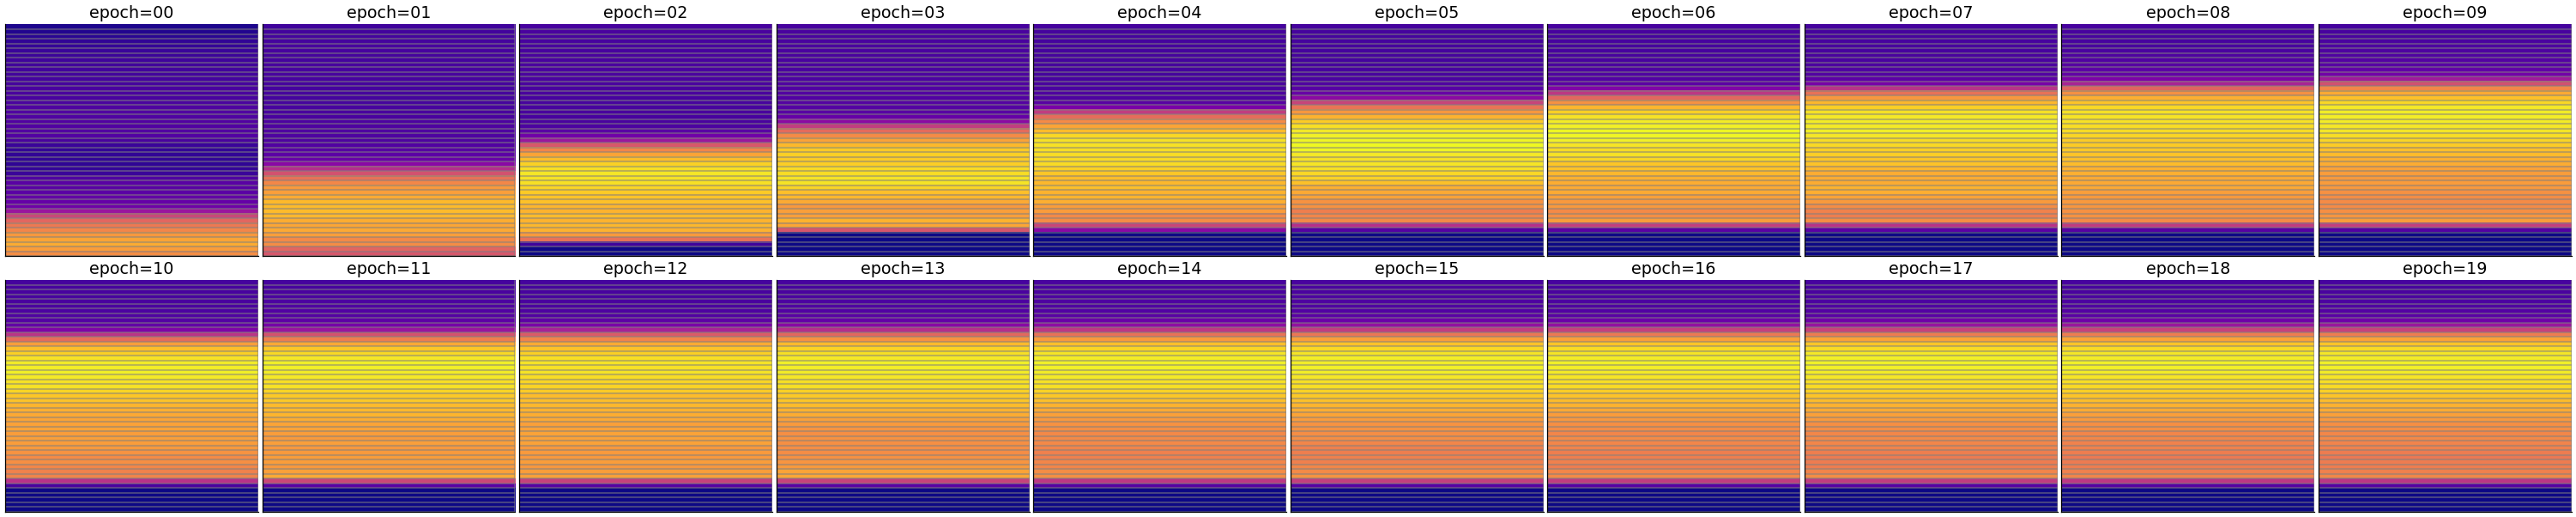

In [6]:
space = "flat"
# space = "schaefer400"
# space = "mni_cortex"
version = 6

dataset = "nsd_cococlip"
# dataset = "hcpya_task21"

# grids = get_grid_trajectory(space=space, trial=1)
grids = np.stack(
    [
        get_grid_trajectory(space=space, trial=ii, dataset=dataset, version=version)
        for ii in range(1, 6)
    ]
).mean(axis=0)
# grids = get_grid_trajectory(space=space, trial=1, dataset=dataset, version=version)
# grids = get_grid_trajectory(space=space, trial=1, dataset=dataset, version=version, split="train", metric="loss")

nc = 10
nr = len(grids) // nc
ploth = plotw = 1.0

f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, nr * ploth))
axs = axs.flatten()

vmin = grids.min()
vmax = grids.max()

for ii, ax in enumerate(axs):
    plt.sca(ax)
    plt.imshow(grids[ii], interpolation="none", cmap="plasma", vmin=vmin, vmax=vmax, aspect="auto")
    plt.xticks(np.arange(0, grids.shape[2]) + 0.5, [])
    plt.yticks(np.arange(0, grids.shape[1]) + 0.5, [])
    plt.grid()
    plt.title(f"epoch={ii:02d}", fontsize="small", pad=2)
    ax.tick_params(length=0)

plt.tight_layout(pad=0.2)

Text(0.5, 0, 'epoch')

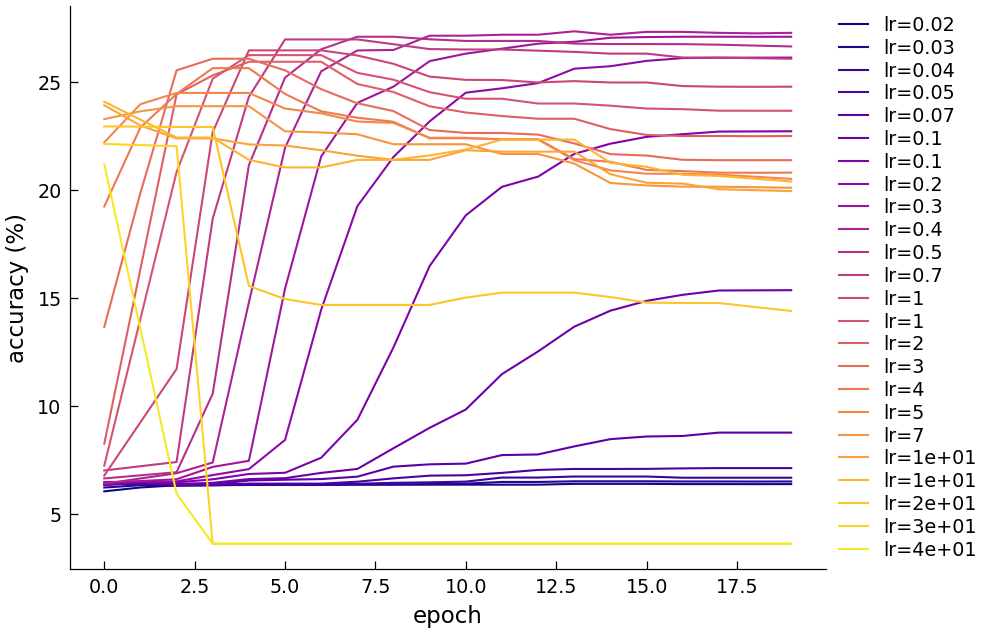

In [7]:
cidx = 0

lr_scale_grid, wd_scale_grid = hparam_grids[version]
nlr = len(lr_scale_grid)
nwd = len(wd_scale_grid)

f, ax = plt.subplots()

cmap = plt.get_cmap("plasma")

stride = 2

for ii in range(nlr // stride):
    lr = lr_scale_grid[ii * stride]
    y = 100 * grids[:, ii * stride, cidx]
    ymed = pd.Series(y).rolling(5, min_periods=1, center=True).median().values
    color = cmap(ii * stride / (nlr - 1))
    # plt.plot(y, "o", color=color, alpha=0.3)
    plt.plot(ymed, "-", color=color, label=f"lr={lr:.0g}")

plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.ylabel("accuracy (%)")
plt.xlabel("epoch")

lr scale: 0.32, acc: 27.4%


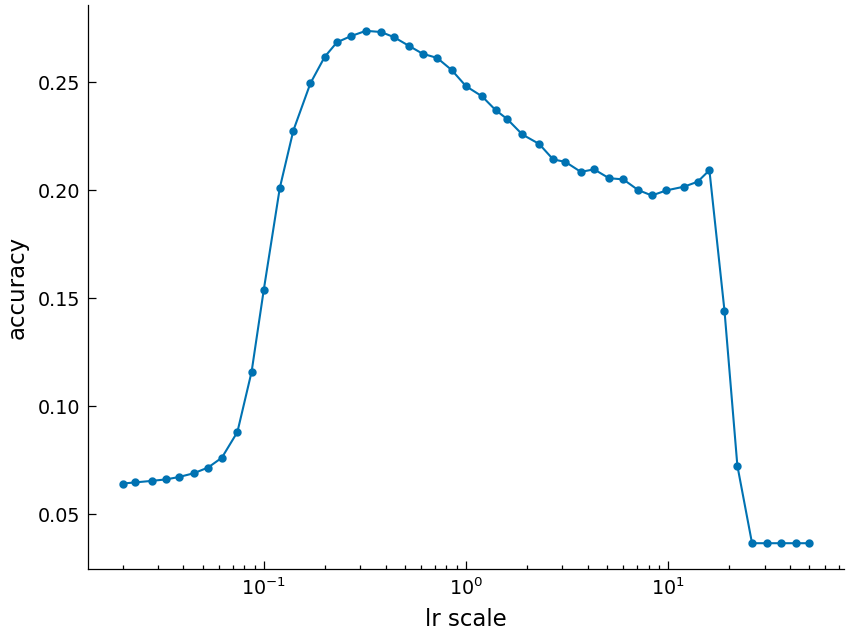

In [8]:
cidx = 0

lr_scale_grid, wd_scale_grid = hparam_grids[version]
nlr = len(lr_scale_grid)
nwd = len(wd_scale_grid)

f, ax = plt.subplots()
ax.set_xscale("log")

x = lr_scale_grid
y = grids[-1, :, cidx]
plt.plot(x, y, "o-")

plt.ylabel("accuracy")
plt.xlabel("lr scale")

idx = np.argmax(y)
print(f"lr scale: {x[idx]:.2g}, acc: {y[idx] * 100:.1f}%")

schaefer400: lr scale: 8.3, acc: 25.6%
flat: lr scale: 1.2, acc: 27.8%
mni_cortex: lr scale: 0.44, acc: 24.3%


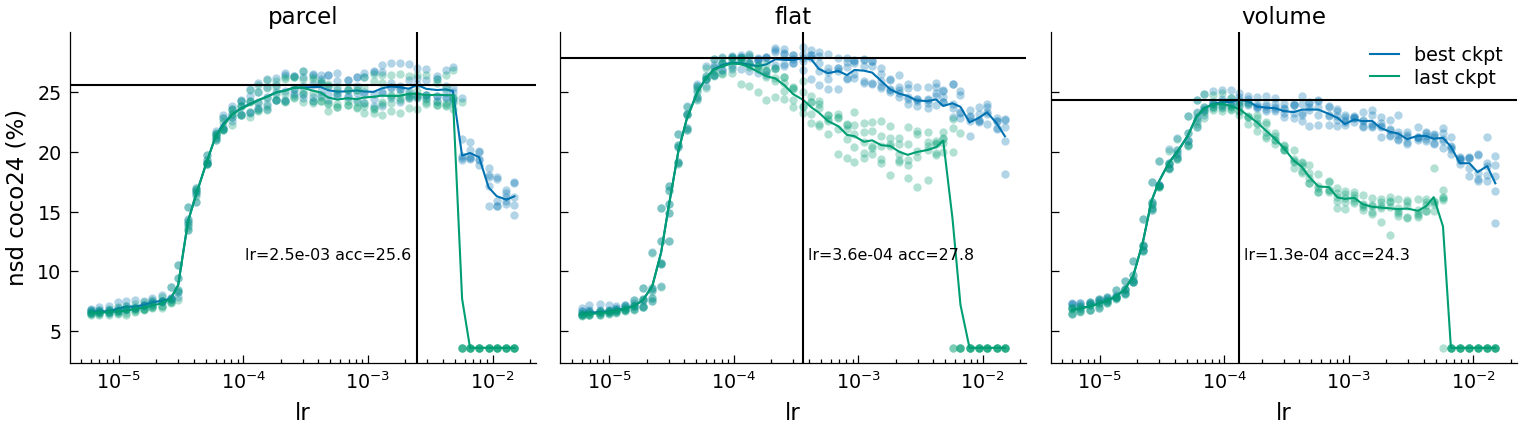

In [9]:
version = 6
dataset = "nsd_cococlip"
show_best = True

cidx = 0
lr_scale_grid, wd_scale_grid = hparam_grids[version]
nlr = len(lr_scale_grid)
nwd = len(wd_scale_grid)

nr, nc = 1, 3
plotw = 0.8 * 2 * PLOTW / nc
ploth = 0.9 * plotw
f, axs = plt.subplots(nr, nc, figsize=(plotw * nc, ploth * nr), sharex=True, sharey=True)

# base_lr = 1e-3
base_lr = 3e-4
x = base_lr * np.array(lr_scale_grid)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ii, space in enumerate(SPACE_NAMES):
    ax = axs[ii]
    ax.set_xscale("log")
    plt.sca(ax)

    grids = [
        get_grid_trajectory(space=space, trial=ii, dataset=dataset, version=version)
        for ii in range(1, 6)
    ]
    all_grids = np.stack(grids)
    grids = all_grids.mean(axis=0)

    y = 100 * grids[:, :, cidx].max(axis=0)
    plt.plot(x, y, "-", label="best ckpt", color=colors[0])
    for jj in range(len(all_grids)):
        plt.plot(
            x,
            100 * all_grids[jj, :, :, cidx].max(axis=0),
            "o",
            ms=2,
            color=colors[0],
            alpha=0.3,
            mew=0.0,
        )

    y = 100 * grids[-1, :, cidx]
    plt.plot(x, y, "-", label="last ckpt", color=colors[1])
    for jj in range(len(all_grids)):
        plt.plot(
            x, 100 * all_grids[jj, -1, :, cidx], "o", ms=2, color=colors[1], alpha=0.3, mew=0.0
        )

    if ii == 0:
        plt.ylabel(f"{DATASET_NAMES[dataset].lower()} (%)")
    plt.xlabel("lr")
    plt.title(SPACE_NAMES[space], fontsize="medium")

    if show_best:
        y = 100 * grids[:, :, cidx].max(axis=0)
    else:
        y = 100 * grids[-1, :, cidx]
    idx = np.argmax(y)
    lrs = lr_scale_grid[idx]
    lr = x[idx]
    acc = y[idx]
    print(f"{space}: lr scale: {lrs:.2g}, acc: {acc:.1f}%")

    plt.axvline(x[idx], color="k", lw=0.5)
    plt.axhline(y[idx], color="k", lw=0.5)
    if ii == 0:
        plt.text(
            0.9 * x[idx], 12, f"lr={lr:.1e} acc={acc:.1f}", ha="right", va="top", fontsize="x-small"
        )
    else:
        plt.text(
            1.1 * x[idx], 12, f"lr={lr:.1e} acc={acc:.1f}", ha="left", va="top", fontsize="x-small"
        )

    if ii == 2:
        plt.legend(fontsize="small")

plt.tight_layout()
f.savefig("results/probe_lr_grid.pdf")